## Datos sobre remesas de trabajadores - ECUADOR - 2025

Las remesas de trabajadores recibidas en Ecuador se refieren al envío de dinero que los emigrantes ecuatorianos que residen y trabajan en el extranjero remiten a sus familiares y/o contactos en el Ecuador.

Mientras que, las remesas de trabajadores enviadas desde Ecuador se refieren al envío de recursos monetarios por parte de ciudadanos extranjeros, residentes en Ecuador, a sus familiares y/o contactos que residen en el resto del mundo.

Tanto las remesas enviadas como recibidas forman parte de Balanza de Pagos a través del Ingreso Secundario.

https://contenido.bce.fin.ec/documentos/informacioneconomica/SectorExterno/ix_Remesas.html

# Análisis Exploratorio y Visualizaciones

## 1. Carga y exploración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot

# Cargar datos
df = pd.read_csv('BDD_Remesas_de_trabajadores.csv', sep=';', low_memory = False)

# Información básica
print(f"Shape: {df.shape}")
print(f"Años disponibles: {df['anio'].unique()}")
print(f"\nTipos de operación: {df['descr_tipo_operacion'].unique()}")
print(f"\nTipos de transacción: {df['descr_tipo_transaccion'].unique()}")

Shape: (115867, 19)
Años disponibles: [2025]

Tipos de operación: ['REMESAS DE TRABAJADORES']

Tipos de transacción: ['ENVIADAS' 'RECIBIDAS']


In [2]:
df.isnull().sum()

anio                      0
mes                       0
trimestre                 0
descr_tipo_operacion      0
descr_tipo_transaccion    0
descr_tipo_entidad        0
descr_continente          0
cod_pais                  0
descr_pais                0
descr_region              0
cod_provincia             0
descr_provincia           0
cod_canton                0
descr_canton              0
cod_parroquia             0
descr_parroquia           0
descr_sector              0
monto_USD                 0
numero_giros              0
dtype: int64

In [3]:
# Tranformamos la columna monto_USD a flotante.
df["monto_USD"] = pd.to_numeric(
    df["monto_USD"]
    .astype(str)  # Aseguramos que todas las entradas son strings
    .str.strip()  # Elimina espacios en blanco al inicio y al final
    .str.replace(r'\.', '', regex=True) # Elimina los separadores de miles (puntos), usando regex para mayor robustez
    .str.replace(',', '.', regex=False),  # Reemplaza el separador decimal (coma) por un punto
    errors='coerce' # Convierte valores no válidos a NaN
)

df['numero_giros'] = pd.to_numeric(df['numero_giros'], errors='coerce')



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115867 entries, 0 to 115866
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   anio                    115867 non-null  int64  
 1   mes                     115867 non-null  int64  
 2   trimestre               115867 non-null  object 
 3   descr_tipo_operacion    115867 non-null  object 
 4   descr_tipo_transaccion  115867 non-null  object 
 5   descr_tipo_entidad      115867 non-null  object 
 6   descr_continente        115867 non-null  object 
 7   cod_pais                115867 non-null  int64  
 8   descr_pais              115867 non-null  object 
 9   descr_region            115867 non-null  object 
 10  cod_provincia           115867 non-null  int64  
 11  descr_provincia         115867 non-null  object 
 12  cod_canton              115867 non-null  int64  
 13  descr_canton            115867 non-null  object 
 14  cod_parroquia       

In [5]:
df.head()

,anio,mes,trimestre,descr_tipo_operacion,descr_tipo_transaccion,descr_tipo_entidad,descr_continente,cod_pais,descr_pais,descr_region,cod_provincia,descr_provincia,cod_canton,descr_canton,cod_parroquia,descr_parroquia,descr_sector,monto_USD,numero_giros
0,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90110,ROCAFUERTE,URBANO,714.0,4
1,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90112,TARQUI,URBANO,274774.0,13
2,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90114,XIMENA,URBANO,68094.0,5
3,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,13,MANABÍ,1301,PORTOVIEJO,130102,12 DE MARZO,URBANO,1050.0,3
4,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,13,MANABÍ,1308,MANTA,130802,MANTA,URBANO,173554.0,4


In [6]:
# Porcentaje de eliminación 
#100 - df_clean.shape[0]/df.shape[0]*100

In [7]:
#df_clean.head()

## El datset limpio, contiene 19 columnas..
Con información geográfica detallada (continente, país, provincia, cantón, parroquia, sector) y las variables clave:

- monto_USD : valor total de las remesas en dólares

- numero_giros : cantidad de transacciones

Además, las columnas descr_tipo_transaccion y descr_tipo_entidad indican la dirección (ENVIADAS / RECIBIDAS) y el canal (BANCOS, REMESADORAS, COOPERATIVAS...).

## Resumen global por tipo de transación y entidad

In [8]:
# Agrupar por tipo de transacción y entidad
resumen = df.groupby(['descr_tipo_transaccion', 'descr_tipo_entidad']).agg(
    total_monto=('monto_USD', 'sum'),
    total_giros=('numero_giros', 'sum')
).reset_index()

resumen

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros
0,ENVIADAS,BANCOS,4.396585e+08,18375
1,ENVIADAS,REMESADORAS,1.843512e+10,926732
2,RECIBIDAS,BANCOS,1.947878e+11,6767168
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648


In [9]:
# Agrupar por tipo de transacción y entidad
resumen = df.groupby(['descr_tipo_transaccion', 'descr_tipo_entidad']).agg(
    total_monto=('monto_USD', 'sum'),
    total_giros=('numero_giros', 'sum')
).reset_index()

resumen

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros
0,ENVIADAS,BANCOS,4.396585e+08,18375
1,ENVIADAS,REMESADORAS,1.843512e+10,926732
2,RECIBIDAS,BANCOS,1.947878e+11,6767168
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648


In [10]:
enviado = df[df['descr_tipo_transaccion'] == 'ENVIADAS']['monto_USD'].sum() 
recibido = df[df['descr_tipo_transaccion'] == 'RECIBIDAS']['monto_USD'].sum() 
print("Enviado = ",enviado)
print("Recibido = ", recibido)

Enviado =  18874775099.0
Recibido =  304003616143.0


In [11]:
recibido - enviado

np.float64(285128841044.0)

In [12]:
suma_env = resumen.iloc[0, 2]+resumen.iloc[1, 2]
suma_reci = resumen.iloc[2, 2]+resumen.iloc[3, 2]+resumen.iloc[4,2]
#print("Suma envios", suma_env)
bancos_env = resumen.iloc[0, 2]/suma_env*100
remesadoras_env = resumen.iloc[1, 2]/ suma_env*100
#print(suma_reci)
bancos_rec = resumen.iloc[2, 2]/suma_reci*100
coop_rec = resumen.iloc[3, 2]/suma_reci*100
remesadoras_rec = resumen.iloc[4, 2]/suma_reci*100
bancos_rec+remesadoras_rec+coop_rec

datos = [bancos_env, remesadoras_env, bancos_rec, coop_rec, remesadoras_rec]
#print(datos)

resumen['Participacion'] = datos

In [13]:
resumen.head()

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros,Participacion
0,ENVIADAS,BANCOS,4.396585e+08,18375,2.329344
1,ENVIADAS,REMESADORAS,1.843512e+10,926732,97.670656
2,RECIBIDAS,BANCOS,1.947878e+11,6767168,64.074170
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482,3.653820
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648,32.272010


In [14]:
resumen['Participacion'] = resumen['Participacion'].round(2).astype(str) + '%'
resumen

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros,Participacion
0,ENVIADAS,BANCOS,4.396585e+08,18375,2.33%
1,ENVIADAS,REMESADORAS,1.843512e+10,926732,97.67%
2,RECIBIDAS,BANCOS,1.947878e+11,6767168,64.07%
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482,3.65%
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648,32.27%


In [15]:

totales_transaccion = (
    resumen.groupby("descr_tipo_transaccion")["total_monto"]
            .sum()
            .reset_index()
            .rename(columns={"total_monto": "monto_transaccion_total"})
)


In [16]:

totales_transaccion.head()

,descr_tipo_transaccion,monto_transaccion_total
0,ENVIADAS,1.887478e+10
1,RECIBIDAS,3.040036e+11


In [17]:
resumen.head()

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros,Participacion
0,ENVIADAS,BANCOS,4.396585e+08,18375,2.33%
1,ENVIADAS,REMESADORAS,1.843512e+10,926732,97.67%
2,RECIBIDAS,BANCOS,1.947878e+11,6767168,64.07%
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482,3.65%
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648,32.27%


In [18]:
resumen_pct = resumen.merge(
    totales_transaccion,
    on="descr_tipo_transaccion"
)
resumen_pct

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros,Participacion,monto_transaccion_total
0,ENVIADAS,BANCOS,4.396585e+08,18375,2.33%,1.887478e+10
1,ENVIADAS,REMESADORAS,1.843512e+10,926732,97.67%,1.887478e+10
2,RECIBIDAS,BANCOS,1.947878e+11,6767168,64.07%,3.040036e+11
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482,3.65%,3.040036e+11
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648,32.27%,3.040036e+11


In [19]:
resumen_pct["porcentaje_monto"] = (
    resumen_pct["total_monto"] /
    resumen_pct["monto_transaccion_total"] * 100
)
resumen_pct

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros,Participacion,monto_transaccion_total,porcentaje_monto
0,ENVIADAS,BANCOS,4.396585e+08,18375,2.33%,1.887478e+10,2.329344
1,ENVIADAS,REMESADORAS,1.843512e+10,926732,97.67%,1.887478e+10,97.670656
2,RECIBIDAS,BANCOS,1.947878e+11,6767168,64.07%,3.040036e+11,64.074170
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482,3.65%,3.040036e+11,3.653820
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648,32.27%,3.040036e+11,32.272010


In [20]:
resumen_pct[
    ["descr_tipo_transaccion",
     "descr_tipo_entidad",
     "total_monto",
     "porcentaje_monto"]
]

,descr_tipo_transaccion,descr_tipo_entidad,total_monto,porcentaje_monto
0,ENVIADAS,BANCOS,4.396585e+08,2.329344
1,ENVIADAS,REMESADORAS,1.843512e+10,97.670656
2,RECIBIDAS,BANCOS,1.947878e+11,64.074170
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,3.653820
4,RECIBIDAS,REMESADORAS,9.810808e+10,32.272010


In [21]:
resumen_pct = resumen.merge(
    totales_transaccion,
    on="descr_tipo_transaccion"
)

resumen_pct["porcentaje_monto"] = (
    resumen_pct["total_monto"] /
    resumen_pct["monto_transaccion_total"] * 100
)

resumen_pct[
    ["descr_tipo_transaccion",
     "descr_tipo_entidad",
     "total_monto",
     "porcentaje_monto"]
]


,descr_tipo_transaccion,descr_tipo_entidad,total_monto,porcentaje_monto
0,ENVIADAS,BANCOS,4.396585e+08,2.329344
1,ENVIADAS,REMESADORAS,1.843512e+10,97.670656
2,RECIBIDAS,BANCOS,1.947878e+11,64.074170
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,3.653820
4,RECIBIDAS,REMESADORAS,9.810808e+10,32.272010


## Tamaño promedio por transacción

In [22]:

# Monto promedio por giro
resumen["monto_promedio_por_giro"] = (
    resumen["total_monto"] / resumen["total_giros"]
)

resumen


,descr_tipo_transaccion,descr_tipo_entidad,total_monto,total_giros,Participacion,monto_promedio_por_giro
0,ENVIADAS,BANCOS,4.396585e+08,18375,2.33%,23926.993034
1,ENVIADAS,REMESADORAS,1.843512e+10,926732,97.67%,19892.608221
2,RECIBIDAS,BANCOS,1.947878e+11,6767168,64.07%,28784.240941
3,RECIBIDAS,COOPERATIVAS DE AHORRO - CRÉDITO Y MUTUALISTAS,1.110775e+10,251482,3.65%,44169.148699
4,RECIBIDAS,REMESADORAS,9.810808e+10,4421648,32.27%,22188.124448


In [23]:
monto_promedio_env = resumen[resumen['descr_tipo_transaccion'] == 'ENVIADAS']['monto_promedio_por_giro'].sum()
monto_promedio_reci = resumen[resumen['descr_tipo_transaccion'] == 'RECIBIDAS']['monto_promedio_por_giro'].sum()

In [24]:
monto_promedio_env

np.float64(43819.6012551606)

In [25]:
print("Monto total promedio por giro - ENVIADAS = ",monto_promedio_env)
print("Monto total promedio por giro - RECIBIDAS = ",monto_promedio_reci)


Monto total promedio por giro - ENVIADAS =  43819.6012551606
Monto total promedio por giro - RECIBIDAS =  95141.51408765148


## Urbano vs Rural

In [26]:

urbano_rural = (
    df.groupby(["descr_sector",'descr_tipo_transaccion'])
      .agg(
          total_monto=("monto_USD", "sum"),
          total_giros=("numero_giros", "sum")
      )
      .reset_index()
)

urbano_rural["monto_promedio_por_giro"] = (
    urbano_rural["total_monto"] / urbano_rural["total_giros"]
)

urbano_rural


,descr_sector,descr_tipo_transaccion,total_monto,total_giros,monto_promedio_por_giro
0,RURAL,ENVIADAS,2.074286e+09,102690,20199.489833
1,RURAL,RECIBIDAS,2.660025e+10,813993,32678.716956
2,URBANO,ENVIADAS,1.680049e+10,842417,19943.198544
3,URBANO,RECIBIDAS,2.774034e+11,10626305,26105.346053


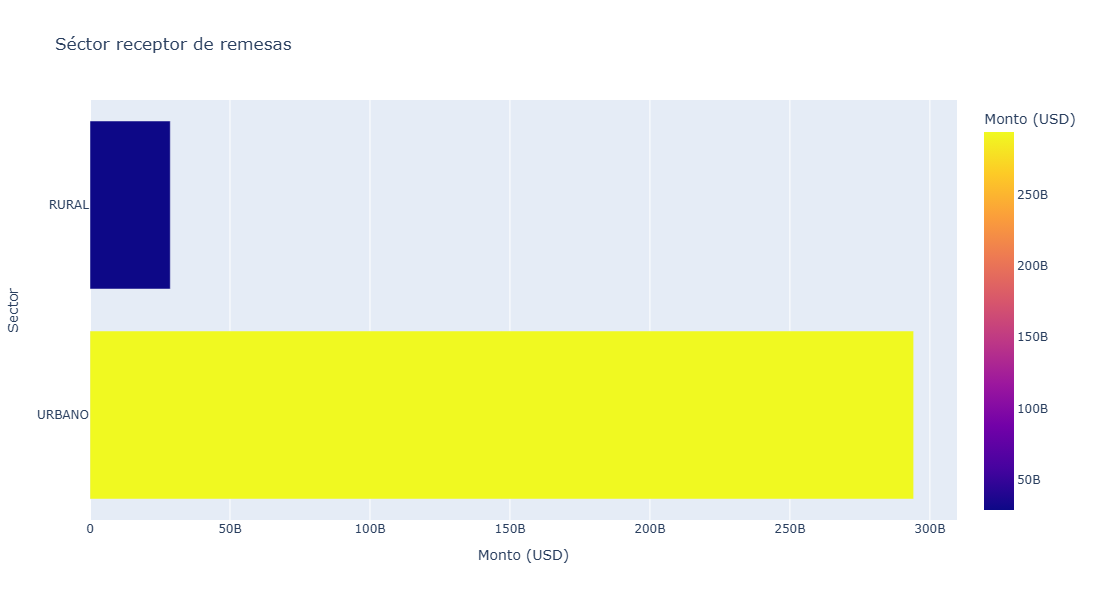

In [27]:
urbano_rural = df.groupby('descr_sector').agg({
    'monto_USD': 'sum'
}).nlargest(2,'monto_USD').reset_index()

fig = px.bar(urbano_rural, x='monto_USD', y='descr_sector',
             title='Séctor receptor de remesas',
             orientation='h',
             labels={'descr_sector': 'Sector', 'monto_USD': 'Monto (USD)'},
             color='monto_USD')
fig.update_layout(height=600)
fig.show()

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3966071285.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


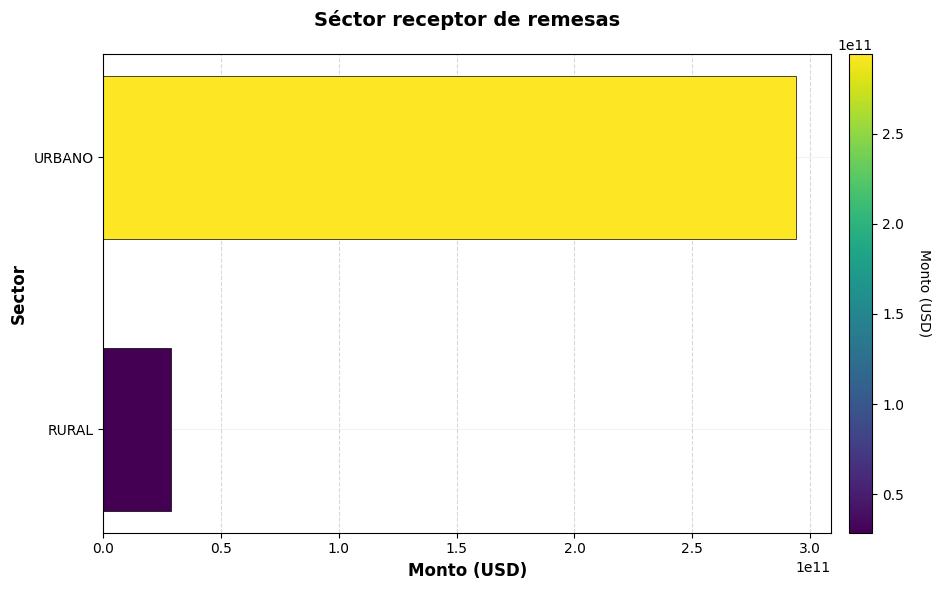

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 🔹 Preparar datos (asegurar orden descendente para mejor visualización)
urbano_rural = urbano_rural.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Crear figura y eje
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)  # 10x6 pulgadas ≈ 1000x600 px

# 🔹 Definir colormap (Viridis como en Plotly)
norm = mcolors.Normalize(vmin=urbano_rural['monto_USD'].min(), 
                         vmax=urbano_rural['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(urbano_rural['monto_USD']))

# 🔹 Crear barras horizontales
bars = ax.barh(urbano_rural['descr_sector'], 
               urbano_rural['monto_USD'],
               color=colors,
               edgecolor='black',
               linewidth=0.5,
               height=0.6)

# # 🔹 Agregar etiquetas de valor al final de cada barra
# for bar in bars:
#     width = bar.get_width()
#     ax.text(width * 1.02,                    # Posición X (2% después de la barra)
#             bar.get_y() + bar.get_height()/2, # Posición Y (centro de la barra)
#             f'${width:,.0f}',                # Texto formateado
#             va='center',                     # Alineación vertical
#             fontsize=10,
#             fontweight='bold',
#             color='black')

# 🔹 Etiquetas y título
ax.set_xlabel('Monto (USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sector', fontsize=12, fontweight='bold')
ax.set_title('Séctor receptor de remesas', fontsize=14, fontweight='bold', pad=20)

# 🔹 Mejorar ejes y grid
ax.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
ax.grid(axis='y', linestyle='-', alpha=0.1, color='gray')
ax.set_axisbelow(True)  # Grid detrás de las barras

# 🔹 Barra de color (colorbar) para referencia del gradiente
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Monto (USD)', rotation=270, labelpad=20, fontsize=10)

# 🔹 Ajustar márgenes para que no se corten etiquetas
plt.tight_layout()

# 🔹 Mostrar gráfica
plt.show()

# 🔹 Guardar en alta resolución (opcional)
fig.savefig("remesas_sector_.png", dpi=300, bbox_inches='tight', facecolor='white')

## Provincias

In [29]:

provincias = (
    df.groupby(["descr_provincia",'descr_tipo_transaccion'])
      .agg(
          total_monto=("monto_USD", "sum"),
          total_giros=("numero_giros", "sum")
      )
      .reset_index()
)

provincias["monto_promedio_por_giro"] = (
    provincias["total_monto"] / provincias["total_giros"]
)

provincias_sorted = provincias.sort_values(
    by="monto_promedio_por_giro", ascending=False
)

provincias_sorted.head(10)


,descr_provincia,descr_tipo_transaccion,total_monto,total_giros,monto_promedio_por_giro
45,TUNGURAHUA,RECIBIDAS,1.039445e+10,300766,34559.932216
1,AZUAY,RECIBIDAS,4.666445e+10,1388706,33602.831280
21,IMBABURA,RECIBIDAS,4.384775e+09,132034,33209.437107
11,COTOPAXI,RECIBIDAS,4.962288e+09,154790,32058.194567
23,LOJA,RECIBIDAS,6.608788e+09,212680,31073.857387
47,ZAMORA CHINCHIPE,RECIBIDAS,1.199493e+09,39228,30577.464184
7,CAÑAR,RECIBIDAS,1.794019e+10,591789,30315.179567
3,BOLÍVAR,RECIBIDAS,1.087662e+09,38232,28448.996364
9,CHIMBORAZO,RECIBIDAS,8.985748e+09,319444,28129.337208
19,GUAYAS,RECIBIDAS,8.942924e+10,3179677,28125.259335


In [30]:
diez_total = provincias_sorted.sort_values(by = 'total_monto', ascending=False).head(10)

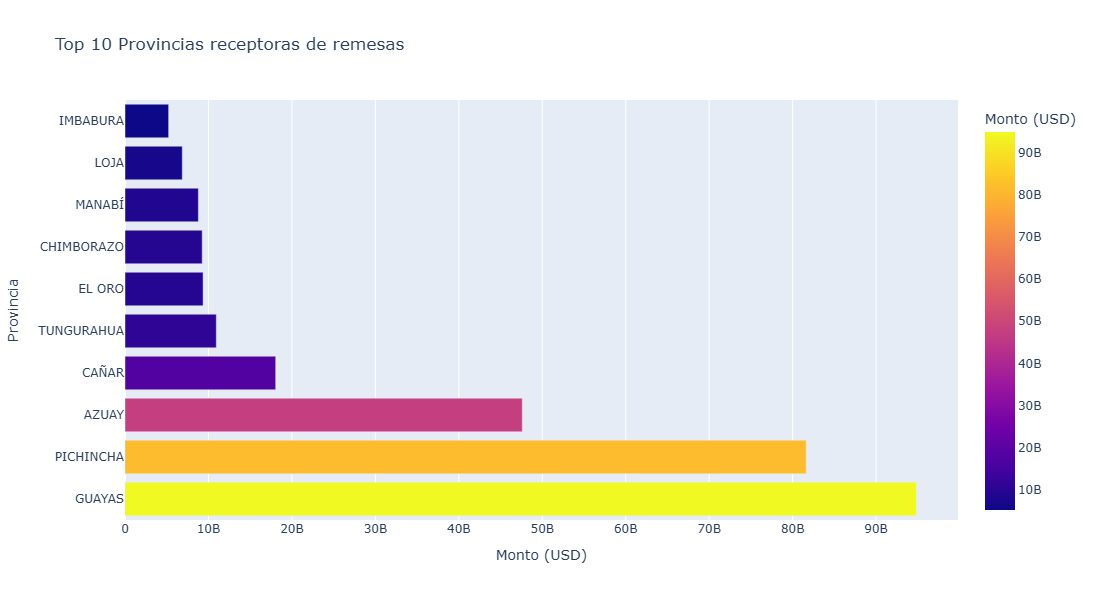

In [31]:
top_provincias = df.groupby('descr_provincia').agg({
    'monto_USD': 'sum'
}).nlargest(10, 'monto_USD').reset_index()

fig = px.bar(top_provincias, x='monto_USD', y='descr_provincia',
             title='Top 10 Provincias receptoras de remesas',
             orientation='h',
             labels={'descr_provincia': 'Provincia', 'monto_USD': 'Monto (USD)'},
             color='monto_USD')
fig.update_layout(height=600)
fig.show()

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3632794800.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3632794800.py:52: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


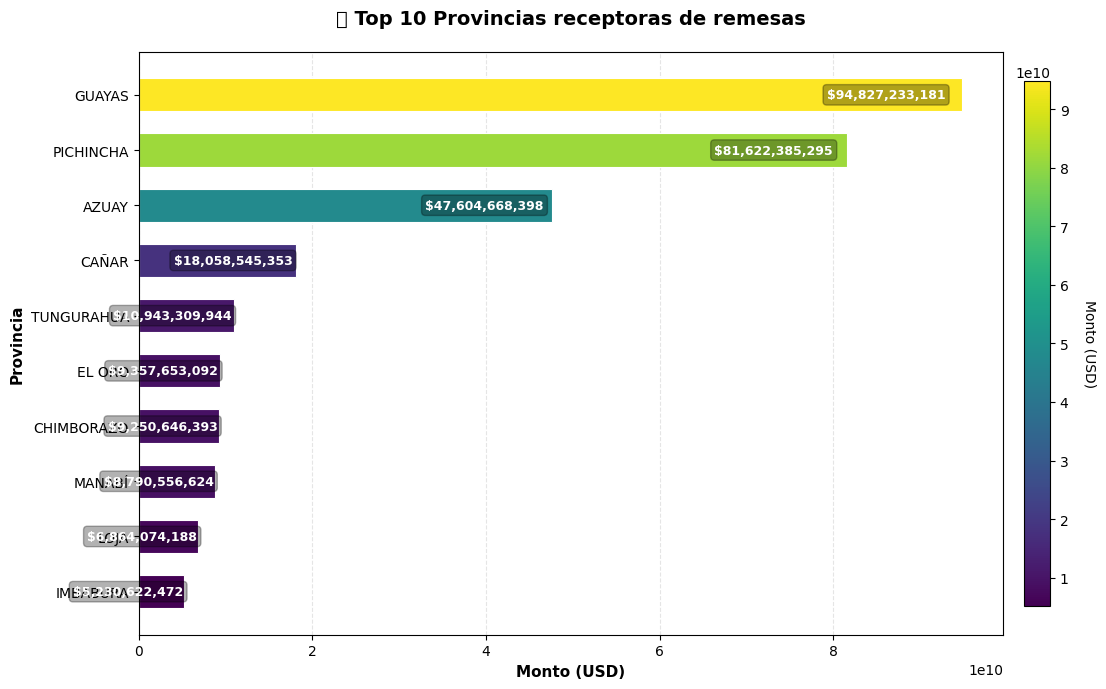

In [32]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 🔹 Preparar datos: orden ascendente para que el mayor quede arriba
top_provincias = top_provincias.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Crear figura
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

# 🔹 Colormap
norm = mcolors.Normalize(vmin=top_provincias['monto_USD'].min(), 
                         vmax=top_provincias['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(top_provincias['monto_USD']))

# 🔹 Barras horizontales
bars = ax.barh(top_provincias['descr_provincia'], 
               top_provincias['monto_USD'],
               color=colors,
               edgecolor='white',  # Borde blanco para separar barras
               linewidth=0.8,
               height=0.6)

# 🔹 Etiquetas DENTRO de las barras (estético y limpio)
for bar in bars:
    width = bar.get_width()
    # Posición: 98% del ancho de la barra (derecha, dentro)
    ax.text(width * 0.98, bar.get_y() + bar.get_height()/2, 
            f'${width:,.0f}', 
            va='center', ha='right',           # Alineación vertical centrada, horizontal derecha
            fontsize=9, fontweight='bold', 
            color='white',                     # Texto blanco para contraste
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.3))  # Fondo sutil

# 🔹 Títulos y etiquetas
ax.set_xlabel('Monto (USD)', fontsize=11, fontweight='bold')
ax.set_ylabel('Provincia', fontsize=11, fontweight='bold')
ax.set_title('🏆 Top 10 Provincias receptoras de remesas', 
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Grid suave
ax.grid(axis='x', linestyle='--', alpha=0.2, color='gray')
ax.set_axisbelow(True)

# 🔹 Barra de color (opcional, si quieres mantenerla)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label('Monto (USD)', rotation=270, labelpad=20, fontsize=10)

# 🔹 Ajustar márgenes
plt.tight_layout()
plt.show()

# Guardar (opcional)
# fig.savefig("top_provincias_clean.png", dpi=300, bbox_inches='tight', facecolor='white')

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3110971813.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3110971813.py:54: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


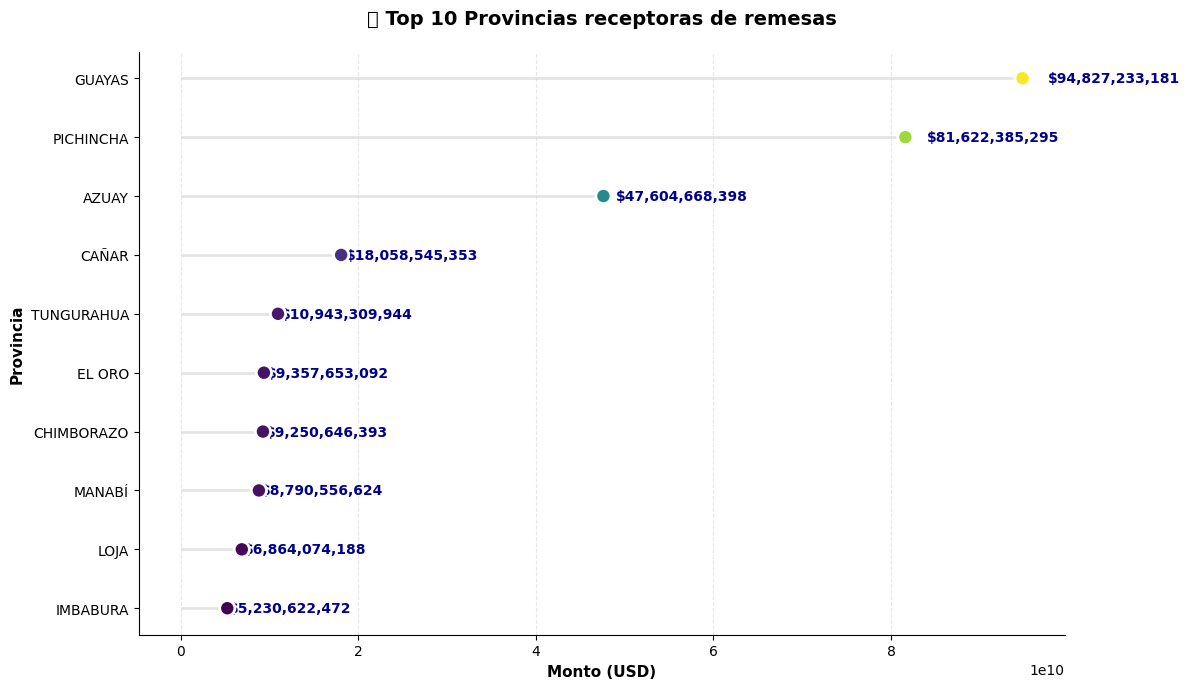

In [33]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 🔹 Preparar datos
top_provincias = top_provincias.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Crear figura
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

# 🔹 Colormap para los puntos
norm = mcolors.Normalize(vmin=top_provincias['monto_USD'].min(), 
                         vmax=top_provincias['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(top_provincias['monto_USD']))

# 🔹 Líneas horizontales (el "palo" del lollipop)
ax.hlines(top_provincias['descr_provincia'], 
          xmin=0, 
          xmax=top_provincias['monto_USD'], 
          color='lightgray', 
          linewidth=2, 
          alpha=0.6)

# 🔹 Puntos finales (el "caramelo")
ax.scatter(top_provincias['monto_USD'], 
           top_provincias['descr_provincia'], 
           color=colors, 
           s=120,  # Tamaño del punto
           edgecolors='white', 
           linewidth=2,
           zorder=5)

# 🔹 Etiquetas de valor AL FINAL de cada línea (siempre visibles)
for _, row in top_provincias.iterrows():
    ax.text(row['monto_USD'] * 1.03,  # 3% de margen derecho
            row['descr_provincia'], 
            f'${row["monto_USD"]:,.0f}', 
            va='center', 
            fontsize=10, 
            fontweight='bold',
            color='darkblue')

# 🔹 Estilo general
ax.set_xlabel('Monto (USD)', fontsize=11, fontweight='bold')
ax.set_ylabel('Provincia', fontsize=11, fontweight='bold')
ax.set_title('🏆 Top 10 Provincias receptoras de remesas', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 🔹 Ajustar márgenes
plt.tight_layout()
plt.show()
# fig.savefig("lollipop_provincias.png", dpi=300, bbox_inches='tight')

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3511691213.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3511691213.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


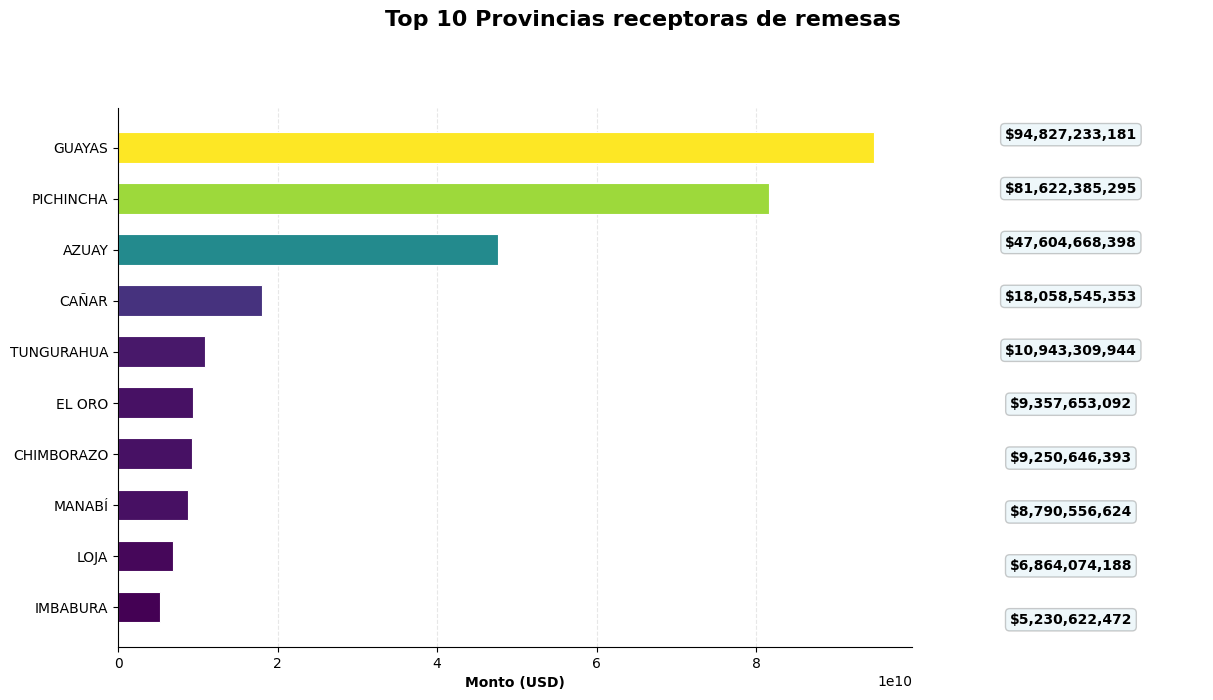

In [40]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

top_provincias = top_provincias.sort_values('monto_USD', ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), 
                               gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.05})

# 🔹 Colormap
norm = mcolors.Normalize(vmin=top_provincias['monto_USD'].min(), 
                         vmax=top_provincias['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(top_provincias['monto_USD']))

# 🔹 Panel izquierdo: Barras SIN etiquetas
bars = ax1.barh(top_provincias['descr_provincia'], 
                top_provincias['monto_USD'],
                color=colors,
                edgecolor='white',
                linewidth=0.8,
                height=0.6)
ax1.set_xlabel('Monto (USD)', fontweight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 🔹 Panel derecho: Valores alineados como tabla
for i, (_, row) in enumerate(top_provincias.iterrows()):
    ax2.text(0.5, i, f'${row["monto_USD"]:,.0f}', 
             ha='center', va='center', 
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.2))

ax2.set_xlim(0, 1)
ax2.set_ylim(-0.5, len(top_provincias)-0.5)
ax2.axis('off')  # Ocultar ejes del panel de valores

# 🔹 Título general
fig.suptitle('Top 10 Provincias receptoras de remesas', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()
fig.savefig("top_provincias.png", dpi=300, bbox_inches='tight')

In [35]:
#pip install squarify

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [41]:
# # Requiere: pip install squarify
# import squarify
# import matplotlib.pyplot as plt

# top_provincias = top_provincias.sort_values('monto_USD', ascending=False).reset_index(drop=True)

# # 🔹 Preparar datos para squarify
# sizes = top_provincias['monto_USD'].tolist()
# labels = [f'{row["descr_provincia"]}\n${row["monto_USD"]:,.0f}' 
#           for _, row in top_provincias.iterrows()]
# ccmap = plt.cm.get_cmap('viridis_r')
# colors = cmap([i / len(sizes) for i in range(len(sizes))])

# # 🔹 Crear treemap
# fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
# squarify.plot(sizes=sizes, 
#               label=labels, 
#               color=colors,
#               alpha=0.8,
#               pad=True,
#               text_kwargs={'fontsize': 9, 'color': 'white', 'weight': 'bold'},
#               ax=ax)

# ax.set_title('🗺️ Distribución de Remesas por Provincia', 
#              fontsize=14, fontweight='bold', pad=20)
# ax.axis('off')
# plt.tight_layout()
# plt.show()

## Top Cantones

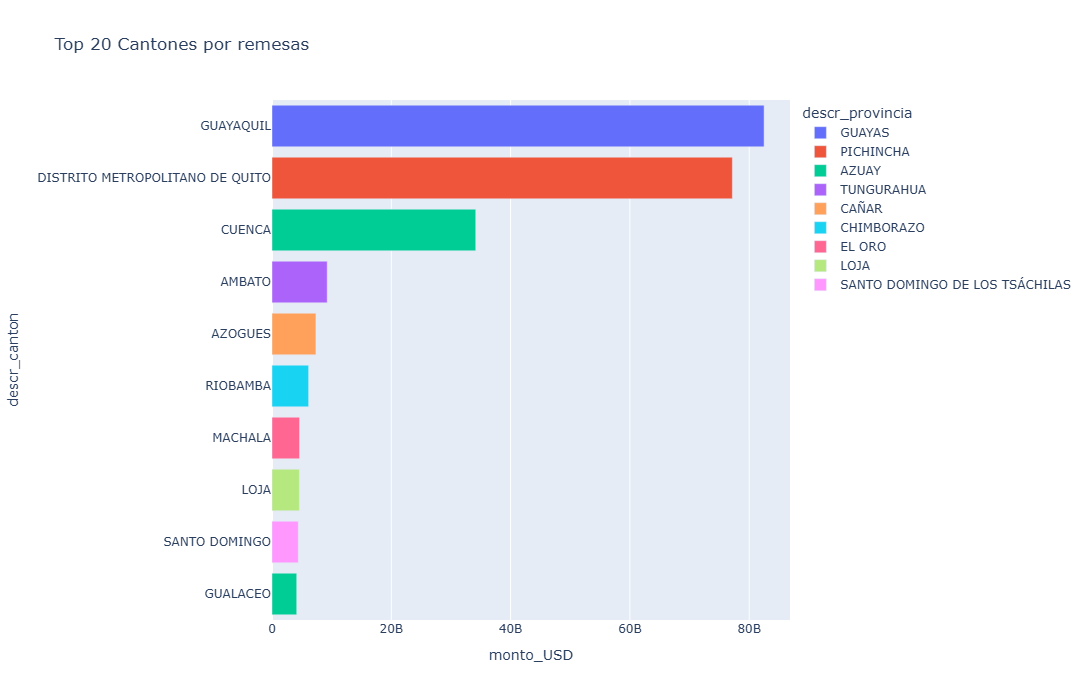

In [45]:
top_cantones = df.groupby(['descr_provincia', 'descr_canton']).agg({
    'monto_USD': 'sum'
}).nlargest(10, 'monto_USD').reset_index()

fig = px.bar(top_cantones, x='monto_USD', y='descr_canton',
             color='descr_provincia',
             title='Top 20 Cantones por remesas',
             orientation='h')
fig.update_layout(height=700, yaxis={'categoryorder': 'total ascending'})
fig.show()

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\1232015523.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20')(range(len(provincias_unicas)))


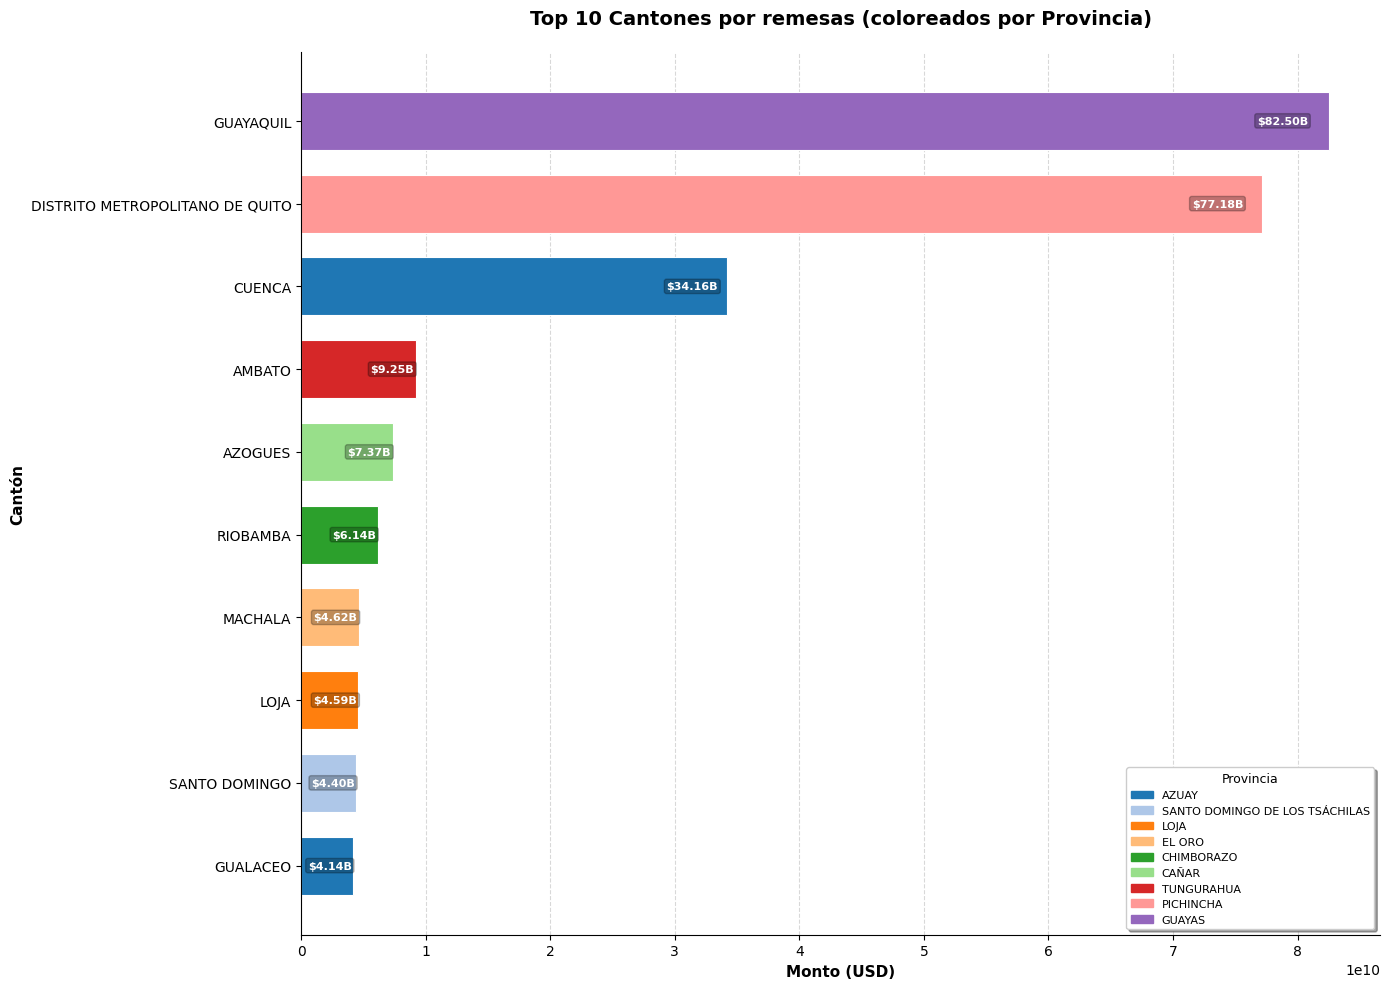

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 🔹 Preparar datos: orden ascendente para que el mayor quede arriba
top_cantones = top_cantones.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Crear mapa de colores por provincia (categórico)
provincias_unicas = top_cantones['descr_provincia'].unique()
# Usar una paleta cualitativa de Matplotlib para categorías distintas
palette = plt.cm.get_cmap('tab20')(range(len(provincias_unicas)))
color_map = dict(zip(provincias_unicas, palette))

# 🔹 Asignar color a cada cantón según su provincia
colors = [color_map[prov] for prov in top_cantones['descr_provincia']]

# 🔹 Crear figura (más ancha para 20 categorías)
fig, ax = plt.subplots(figsize=(14, 10), dpi=100)

# 🔹 Barras horizontales con color por provincia
bars = ax.barh(top_cantones['descr_canton'], 
               top_cantones['monto_USD'],
               color=colors,
               edgecolor='white',
               linewidth=0.8,
               height=0.7)

# 🔹 Etiquetas de valor DENTRO de las barras (formato compacto para montos altos)
def formato_monto(valor):
    if valor >= 1e9:
        return f'${valor/1e9:.2f}B'
    elif valor >= 1e6:
        return f'${valor/1e6:.1f}M'
    elif valor >= 1e3:
        return f'${valor/1e3:.0f}K'
    return f'${valor:,.0f}'

for bar in bars:
    width = bar.get_width()
    # Solo mostrar etiqueta si la barra tiene espacio suficiente
    if width > top_cantones['monto_USD'].max() * 0.05:  # Umbral 5%
        ax.text(width * 0.98, bar.get_y() + bar.get_height()/2, 
                formato_monto(width), 
                va='center', ha='right',
                fontsize=8, fontweight='bold', 
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.25))

# 🔹 Títulos y etiquetas
ax.set_xlabel('Monto (USD)', fontsize=11, fontweight='bold')
ax.set_ylabel('Cantón', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Cantones por remesas (coloreados por Provincia)', 
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Grid y estilo
ax.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 🔹 Leyenda de provincias (solo si hay ≤10 provincias para no saturar)
if len(provincias_unicas) <= 10:
    legend_handles = [mpatches.Patch(color=color_map[prov], label=prov) 
                      for prov in provincias_unicas]
    ax.legend(handles=legend_handles, 
              title='Provincia', 
              loc='lower right', 
              fontsize=8, 
              title_fontsize=9,
              frameon=True,
              fancybox=True,
              shadow=True)

# 🔹 Ajustar márgenes para que no se corten nombres de cantones
plt.tight_layout()
plt.show()

# Guardar en alta resolución (opcional)
fig.savefig("top_cantones_por_provincia.png", dpi=300, bbox_inches='tight', facecolor='white')

## Top parroquias

In [ ]:
df.columns

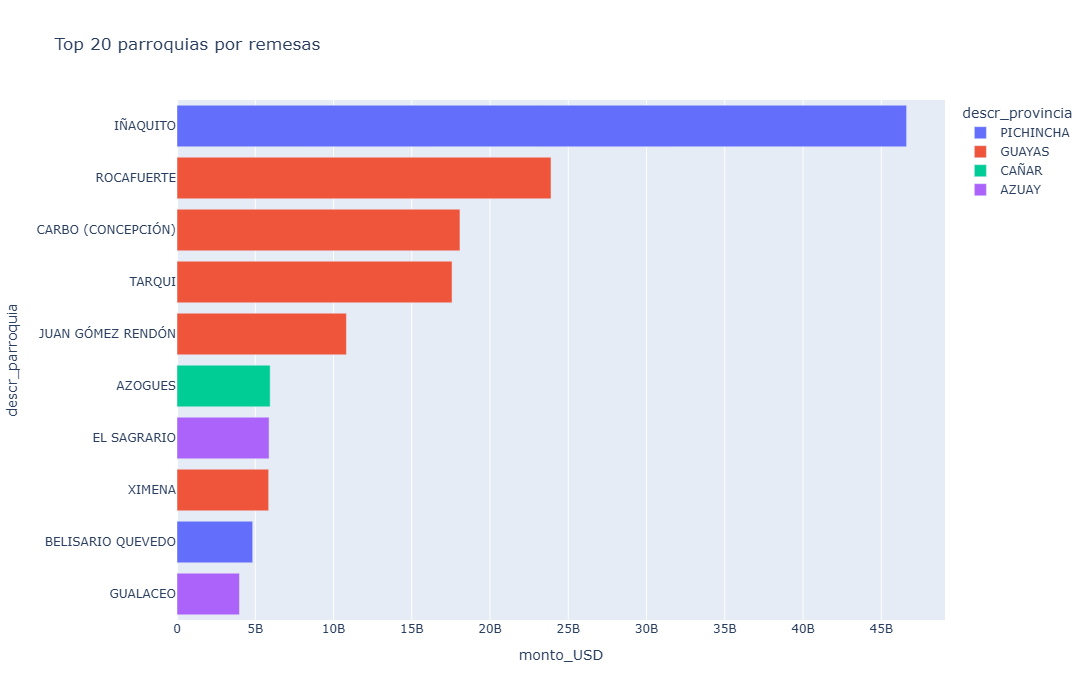

In [48]:
top_parroquias = df.groupby(['descr_provincia', 'descr_parroquia']).agg({
    'monto_USD': 'sum'
}).nlargest(10, 'monto_USD').reset_index()

fig = px.bar(top_parroquias, x='monto_USD', y='descr_parroquia',
             color='descr_provincia',
             title='Top 20 parroquias por remesas',
             orientation='h')
fig.update_layout(height=700, yaxis={'categoryorder': 'total ascending'})
fig.show()

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\4191428343.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20')(range(len(provincias_unicas)))


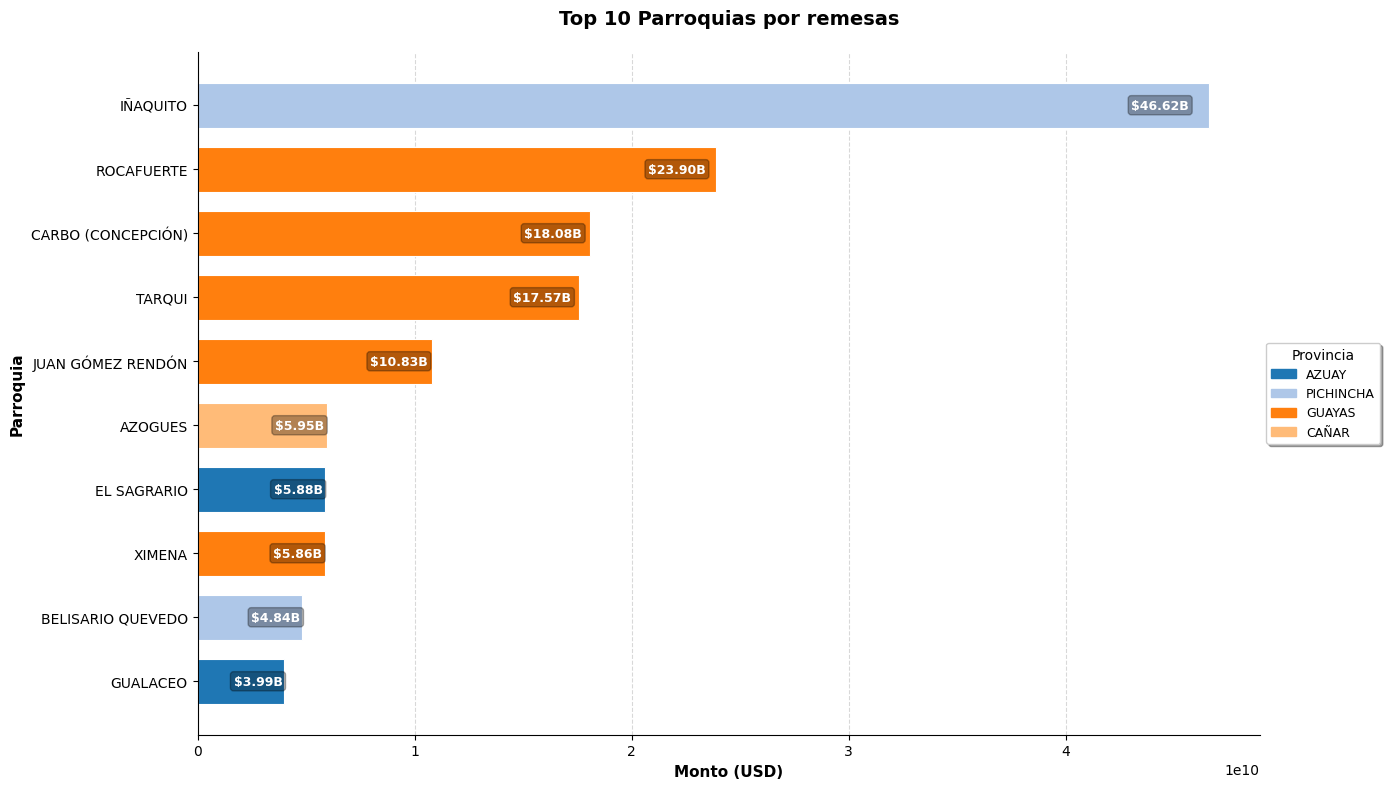

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 🔹 Preparar datos: ordenar ascendente para que el mayor quede arriba
top_parroquias = top_parroquias.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Mapa de colores categórico por provincia
provincias_unicas = top_parroquias['descr_provincia'].unique()
# Paleta cualitativa ideal para categorías distintas (hasta 20 colores únicos)
palette = plt.cm.get_cmap('tab20')(range(len(provincias_unicas)))
color_map = dict(zip(provincias_unicas, palette))
colors = [color_map[prov] for prov in top_parroquias['descr_parroquia'].map(
    dict(zip(top_parroquias['descr_parroquia'], top_parroquias['descr_provincia']))
)]

# 🔹 Función para formato compacto de montos altos
def formato_monto(valor):
    if valor >= 1e9:
        return f'${valor/1e9:.2f}B'
    elif valor >= 1e6:
        return f'${valor/1e6:.1f}M'
    elif valor >= 1e3:
        return f'${valor/1e3:.0f}K'
    return f'${valor:,.0f}'

# 🔹 Crear figura (ajustada para nombres largos de parroquias)
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

# 🔹 Barras horizontales con color por provincia
bars = ax.barh(top_parroquias['descr_parroquia'], 
               top_parroquias['monto_USD'],
               color=colors,
               edgecolor='white',
               linewidth=0.8,
               height=0.7)

# 🔹 Etiquetas de valor DENTRO de las barras (solo si hay espacio)
for bar in bars:
    width = bar.get_width()
    # Mostrar etiqueta solo si la barra ocupa >8% del máximo (evita saturación)
    if width > top_parroquias['monto_USD'].max() * 0.08:
        ax.text(width * 0.98, bar.get_y() + bar.get_height()/2, 
                formato_monto(width), 
                va='center', ha='right',
                fontsize=9, fontweight='bold', 
                color='white',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='black', alpha=0.3))

# 🔹 Títulos y etiquetas
ax.set_xlabel('Monto (USD)', fontsize=11, fontweight='bold')
ax.set_ylabel('Parroquia', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Parroquias por remesas', 
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Grid suave y estilo limpio
ax.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 🔹 Leyenda de provincias (posicionada fuera para no tapar barras)
legend_handles = [mpatches.Patch(color=color_map[prov], label=prov) 
                  for prov in provincias_unicas]
ax.legend(handles=legend_handles, 
          title='Provincia', 
          loc='center left', 
          bbox_to_anchor=(1, 0.5),  # Leyenda fuera del gráfico a la derecha
          fontsize=9, 
          title_fontsize=10,
          frameon=True,
          fancybox=True,
          shadow=True)

# 🔹 Ajustar márgenes para que la leyenda no se corte
plt.tight_layout()
plt.show()

# 🔹 Guardar en alta resolución (opcional)
fig.savefig("top_parroquias_remesas.png", dpi=300, bbox_inches='tight', facecolor='white')
# fig.savefig("top_parroquias_remesas.pdf", bbox_inches='tight')  # Vectorial para publicaciones

## Top 10 Países por Monto de Remesas - RECIBIDAS

In [65]:
df_recibidas = df[df['descr_tipo_transaccion'] == "RECIBIDAS"]
df_recibidas

,anio,mes,trimestre,descr_tipo_operacion,descr_tipo_transaccion,descr_tipo_entidad,descr_continente,cod_pais,descr_pais,descr_region,cod_provincia,descr_provincia,cod_canton,descr_canton,cod_parroquia,descr_parroquia,descr_sector,monto_USD,numero_giros
5725,2025,7,III,REMESAS DE TRABAJADORES,RECIBIDAS,BANCOS,AMÉRICA,32,ARGENTINA,AMAZONÍA,21,SUCUMBÍOS,2101,LAGO AGRIO,210150,NUEVA LOJA,URBANO,120.0,2
5726,2025,7,III,REMESAS DE TRABAJADORES,RECIBIDAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,7,EL ORO,701,MACHALA,70101,LA PROVIDENCIA,URBANO,175.0,2
5727,2025,7,III,REMESAS DE TRABAJADORES,RECIBIDAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,8,ESMERALDAS,801,ESMERALDAS,80103,ESMERALDAS,URBANO,120.0,1
5728,2025,7,III,REMESAS DE TRABAJADORES,RECIBIDAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90104,FEBRES CORDERO,URBANO,130.0,1
5729,2025,7,III,REMESAS DE TRABAJADORES,RECIBIDAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90108,OLMEDO (SAN ALEJO),URBANO,6999.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115862,2025,12,IV,REMESAS DE TRABAJADORES,RECIBIDAS,REMESADORAS,ÁFRICA,818,EGIPTO,COSTA,12,LOS RÍOS,1201,BABAHOYO,120101,CLEMENTE BAQUERIZO,URBANO,588.0,1
115863,2025,12,IV,REMESAS DE TRABAJADORES,RECIBIDAS,REMESADORAS,ÁFRICA,818,EGIPTO,SIERRA,1,AZUAY,101,CUENCA,10114,YANUNCAY,URBANO,200.0,1
115864,2025,12,IV,REMESAS DE TRABAJADORES,RECIBIDAS,REMESADORAS,ÁFRICA,818,EGIPTO,SIERRA,10,IMBABURA,1001,IBARRA,100104,SAN FRANCISCO,URBANO,368.0,1
115865,2025,12,IV,REMESAS DE TRABAJADORES,RECIBIDAS,REMESADORAS,ÁFRICA,834,TANZANIA (REPÚBLICA UNIDA DE),SIERRA,17,PICHINCHA,1701,DISTRITO METROPOLITANO DE QUITO,170110,EL CONDADO,URBANO,650.0,2


In [66]:
# Top 10 países por monto              descr_tipo_transaccion
top_paises = df_recibidas.groupby('descr_pais').agg({
    'monto_USD': 'sum',
    'numero_giros': 'sum'
}).nlargest(10, 'monto_USD').reset_index()

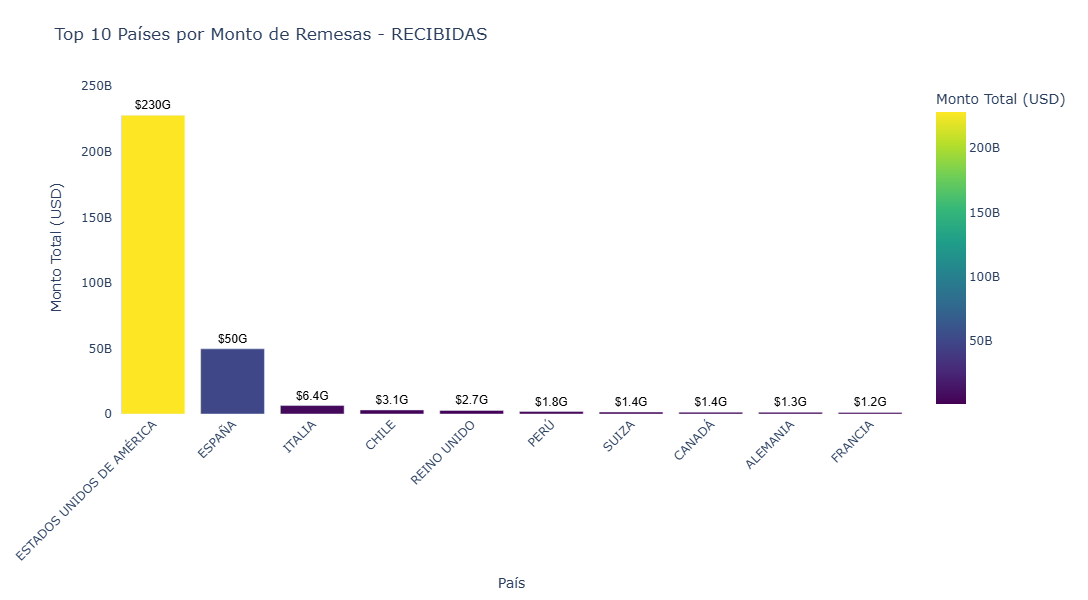

In [67]:
fig = px.bar(top_paises, x='descr_pais', y='monto_USD',
             title='Top 10 Países por Monto de Remesas - RECIBIDAS',
             labels={'descr_pais': 'País', 'monto_USD': 'Monto Total (USD)'},
             color='monto_USD',
             color_continuous_scale='Viridis',
             height=600,  # Altura mayor
             width=1000)  # Ancho mayor

fig.update_layout(
    margin=dict(l=40, r=40, t=80, b=100),  # Márgenes ajustados
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.update_traces(
    texttemplate='%{y:$.2s}',  # Formato compacto: $1.2M, $3.4B, etc.
    textposition='outside',
    textfont=dict(size=12, color='black', family='Arial')
)

fig.show()

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\3534596834.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


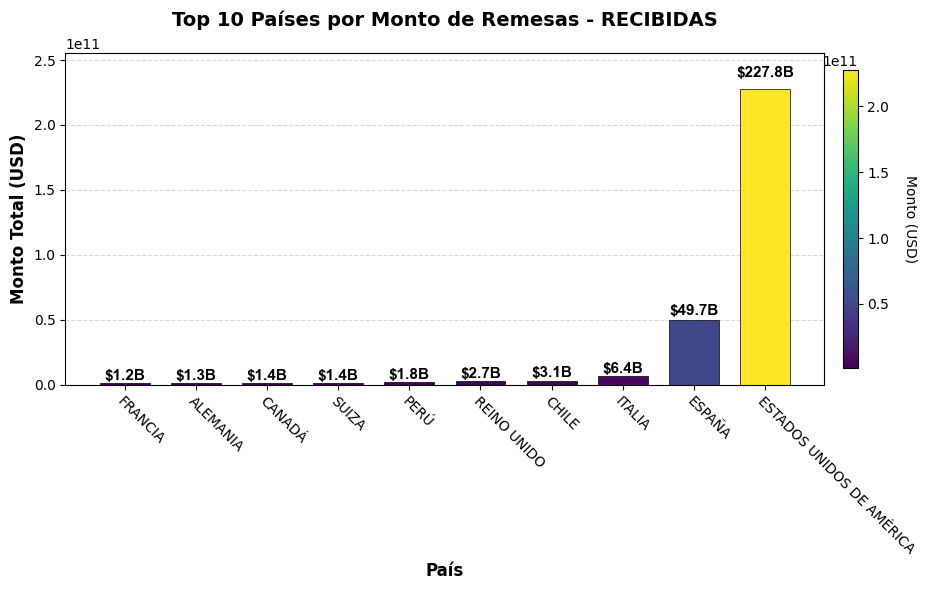

In [75]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df_recibidas = df[df['descr_tipo_transaccion'] == "RECIBIDAS"]
top_paises = df_recibidas.groupby('descr_pais').agg({
    'monto_USD': 'sum',
    'numero_giros': 'sum'
}).nlargest(10, 'monto_USD').reset_index()
# 🔹 Preparar datos
top_paises = top_paises.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Función para formato compacto (igual que %{y:$.2s} de Plotly)
def formato_compacto(valor):
    if valor >= 1e9:
        return f'${valor/1e9:.1f}B'
    elif valor >= 1e6:
        return f'${valor/1e6:.1f}M'
    elif valor >= 1e3:
        return f'${valor/1e3:.1f}K'
    return f'${valor:,.0f}'

# 🔹 Crear figura
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 🔹 Colormap Viridis
norm = mcolors.Normalize(vmin=top_paises['monto_USD'].min(), 
                         vmax=top_paises['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(top_paises['monto_USD']))

# 🔹 Barras verticales
bars = ax.bar(top_paises['descr_pais'], 
              top_paises['monto_USD'],
              color=colors,
              edgecolor='black',
              linewidth=0.5,
              width=0.7)

# 🔹 Etiquetas de valor ENCIMA de las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,  
            height * 1.03,                      # 3% por encima
            formato_compacto(height),           
            ha='center', va='bottom',           
            fontsize=11, fontweight='bold', 
            color='black', family='Arial')

# 🔹 Títulos y etiquetas (🔄 Título actualizado a ENVIADAS)
ax.set_xlabel('País', fontsize=12, fontweight='bold')
ax.set_ylabel('Monto Total (USD)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Países por Monto de Remesas - RECIBIDAS',  # ✅ Actualizado
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Rotar etiquetas X (-45°)
plt.setp(ax.get_xticklabels(), rotation=-45, ha='left', rotation_mode='anchor', fontsize=10)

# 🔹 Grid y fondo blanco
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ✅ SOLUCIÓN CLAVE: Expandir eje Y para evitar que el texto toque el marco
max_valor = top_paises['monto_USD'].max()
ax.set_ylim(0, max_valor * 1.12)  # 12% de margen superior

# 🔹 Colorbar de referencia
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label('Monto (USD)', rotation=270, labelpad=20, fontsize=10)

# 🔹 Ajustar márgenes
plt.tight_layout()
plt.show()

# 🔹 Guardar en alta resolución (opcional)
fig.savefig("top_paises_recibidas.png", dpi=300, bbox_inches='tight', facecolor='white')
# fig.savefig("top_paises_enviadas.pdf", bbox_inches='tight')  # Vectorial

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\4087217354.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


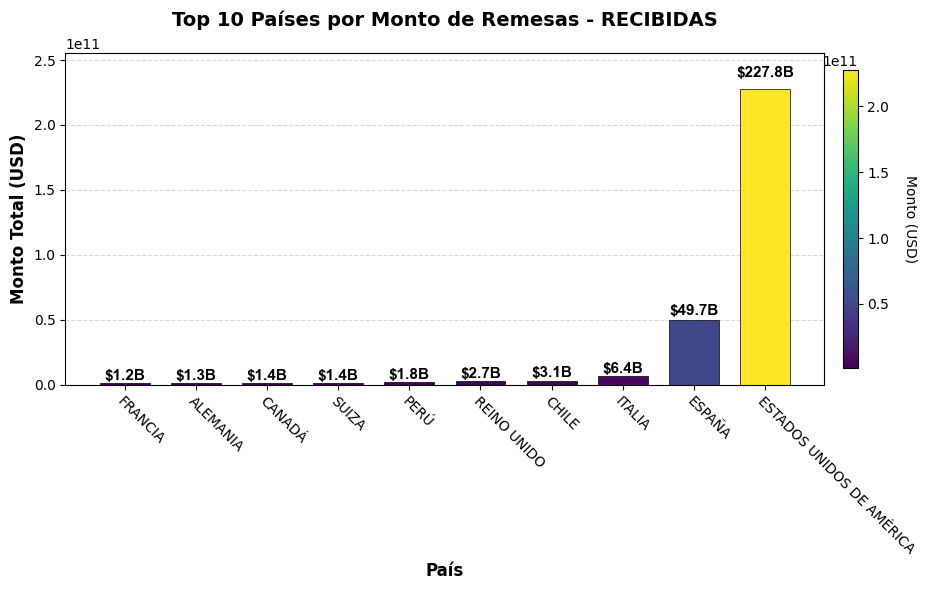

In [76]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 🔹 Preparar datos
df_recibidas = df[df['descr_tipo_transaccion'] == "RECIBIDAS"]
top_paises = df_recibidas.groupby('descr_pais').agg({
    'monto_USD': 'sum',
    'numero_giros': 'sum'
}).nlargest(10, 'monto_USD').reset_index()
top_paises = top_paises.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Función para formato compacto
def formato_compacto(valor):
    if valor >= 1e9:
        return f'${valor/1e9:.1f}B'
    elif valor >= 1e6:
        return f'${valor/1e6:.1f}M'
    elif valor >= 1e3:
        return f'${valor/1e3:.1f}K'
    return f'${valor:,.0f}'

# 🔹 Crear figura
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 🔹 Colormap Viridis
norm = mcolors.Normalize(vmin=top_paises['monto_USD'].min(), 
                         vmax=top_paises['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(top_paises['monto_USD']))

# 🔹 Barras verticales
bars = ax.bar(top_paises['descr_pais'], 
              top_paises['monto_USD'],
              color=colors,
              edgecolor='black',
              linewidth=0.5,
              width=0.7)

# 🔹 Etiquetas de valor ENCIMA de las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,  
            height * 1.03,                      # ✅ 3% por encima (ajustable)
            formato_compacto(height),           
            ha='center', va='bottom',           
            fontsize=11, fontweight='bold', 
            color='black', family='Arial')

# 🔹 Títulos y etiquetas
ax.set_xlabel('País', fontsize=12, fontweight='bold')
ax.set_ylabel('Monto Total (USD)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Países por Monto de Remesas - RECIBIDAS', 
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Rotar etiquetas X
plt.setp(ax.get_xticklabels(), rotation=-45, ha='left', rotation_mode='anchor', fontsize=10)

# 🔹 Grid y fondo
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ✅ SOLUCIÓN PRINCIPAL: Expandir el eje Y para dar espacio al texto superior
max_valor = top_paises['monto_USD'].max()
ax.set_ylim(0, max_valor * 1.12)  # ✅ 12% de margen superior extra

# 🔹 Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label('Monto (USD)', rotation=270, labelpad=20, fontsize=10)

# 🔹 Ajustar márgenes (tight_layout respeta el ylim expandido)
plt.tight_layout()
plt.show()

# Guardar (opcional)
fig.savefig("top_paises_remesas_recibidas.png", dpi=300, bbox_inches='tight', facecolor='white')

## Paises - ENVIADAS

In [52]:

df_enviadas = df[df['descr_tipo_transaccion'] == "ENVIADAS"]
df_enviadas

,anio,mes,trimestre,descr_tipo_operacion,descr_tipo_transaccion,descr_tipo_entidad,descr_continente,cod_pais,descr_pais,descr_region,cod_provincia,descr_provincia,cod_canton,descr_canton,cod_parroquia,descr_parroquia,descr_sector,monto_USD,numero_giros
0,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90110,ROCAFUERTE,URBANO,714.0,4
1,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90112,TARQUI,URBANO,274774.0,13
2,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,9,GUAYAS,901,GUAYAQUIL,90114,XIMENA,URBANO,68094.0,5
3,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,13,MANABÍ,1301,PORTOVIEJO,130102,12 DE MARZO,URBANO,1050.0,3
4,2025,7,III,REMESAS DE TRABAJADORES,ENVIADAS,BANCOS,AMÉRICA,32,ARGENTINA,COSTA,13,MANABÍ,1308,MANTA,130802,MANTA,URBANO,173554.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100174,2025,12,IV,REMESAS DE TRABAJADORES,ENVIADAS,REMESADORAS,ÁFRICA,894,ZAMBIA,COSTA,9,GUAYAS,901,GUAYAQUIL,90103,CARBO (CONCEPCIÓN),URBANO,18695.0,1
100175,2025,12,IV,REMESAS DE TRABAJADORES,ENVIADAS,REMESADORAS,ÁFRICA,894,ZAMBIA,COSTA,9,GUAYAS,901,GUAYAQUIL,90112,TARQUI,URBANO,20.0,1
100176,2025,12,IV,REMESAS DE TRABAJADORES,ENVIADAS,REMESADORAS,ÁFRICA,894,ZAMBIA,COSTA,24,SANTA ELENA,2401,SANTA ELENA,240101,BALLENITA,URBANO,40.0,2
100177,2025,12,IV,REMESAS DE TRABAJADORES,ENVIADAS,REMESADORAS,ÁFRICA,894,ZAMBIA,SIERRA,1,AZUAY,101,CUENCA,10104,EL SAGRARIO,URBANO,30.0,1


In [77]:
# Top 10 países por monto              descr_tipo_transaccion

df_enviadas = df[df['descr_tipo_transaccion'] == "ENVIADAS"]
df_enviadas
top_paises = df_enviadas.groupby('descr_pais').agg({
    'monto_USD': 'sum',
    'numero_giros': 'sum'
}).nlargest(10, 'monto_USD').reset_index()

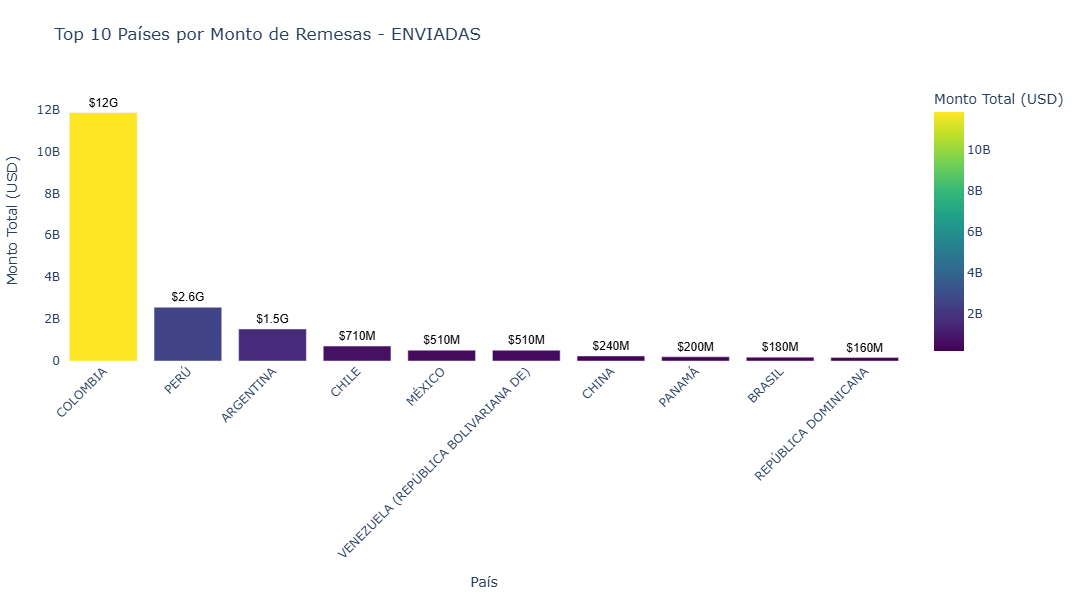

In [78]:
df_enviadas = df[df['descr_tipo_transaccion'] == "ENVIADAS"]
df_enviadas
top_paises = df_enviadas.groupby('descr_pais').agg({
    'monto_USD': 'sum',
    'numero_giros': 'sum'
}).nlargest(10, 'monto_USD').reset_index()

fig = px.bar(top_paises, x='descr_pais', y='monto_USD',
             title='Top 10 Países por Monto de Remesas - ENVIADAS',
             labels={'descr_pais': 'País', 'monto_USD': 'Monto Total (USD)'},
             color='monto_USD',
             color_continuous_scale='Viridis',
             height=600,  # Altura mayor
             width=1000)  # Ancho mayor

fig.update_layout(
    margin=dict(l=40, r=40, t=80, b=100),  # Márgenes ajustados
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.update_traces(
    texttemplate='%{y:$.2s}',  # Formato compacto: $1.2M, $3.4B, etc.
    textposition='outside',
    textfont=dict(size=12, color='black', family='Arial')
)

fig.show()

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_25648\708431371.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


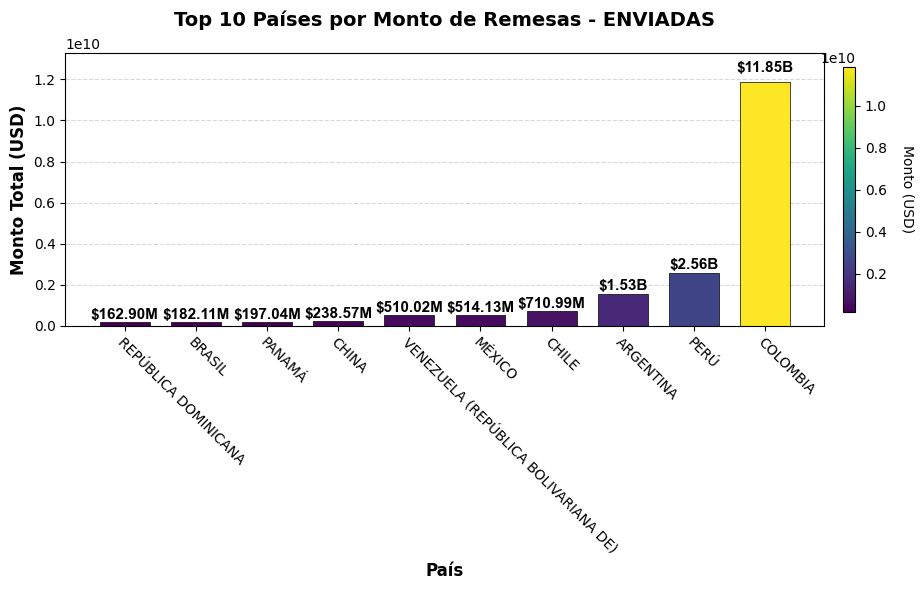

In [80]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 🔹 Preparar datos
df_enviadas = df[df['descr_tipo_transaccion'] == "ENVIADAS"]
df_enviadas
top_paises = df_enviadas.groupby('descr_pais').agg({
    'monto_USD': 'sum',
    'numero_giros': 'sum'
}).nlargest(10, 'monto_USD').reset_index()
top_paises = top_paises.sort_values('monto_USD', ascending=True).reset_index(drop=True)

# 🔹 Función para formato compacto (igual que %{y:$.2s} de Plotly)
def formato_compacto(valor):
    if valor >= 1e9:
        return f'${valor/1e9:.2f}B'
    elif valor >= 1e6:
        return f'${valor/1e6:.2f}M'
    elif valor >= 1e3:
        return f'${valor/1e3:.1f}K'
    return f'${valor:,.0f}'

# 🔹 Crear figura
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 🔹 Colormap Viridis
norm = mcolors.Normalize(vmin=top_paises['monto_USD'].min(), 
                         vmax=top_paises['monto_USD'].max())
cmap = plt.cm.get_cmap('viridis')
colors = cmap(norm(top_paises['monto_USD']))

# 🔹 Barras verticales
bars = ax.bar(top_paises['descr_pais'], 
              top_paises['monto_USD'],
              color=colors,
              edgecolor='black',
              linewidth=0.5,
              width=0.7)

# 🔹 Etiquetas de valor ENCIMA de las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,  
            height * 1.03,                      # 3% por encima
            formato_compacto(height),           
            ha='center', va='bottom',           
            fontsize=11, fontweight='bold', 
            color='black', family='Arial')

# 🔹 Títulos y etiquetas (🔄 Título actualizado a ENVIADAS)
ax.set_xlabel('País', fontsize=12, fontweight='bold')
ax.set_ylabel('Monto Total (USD)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Países por Monto de Remesas - ENVIADAS',  # ✅ Actualizado
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Rotar etiquetas X (-45°)
plt.setp(ax.get_xticklabels(), rotation=-45, ha='left', rotation_mode='anchor', fontsize=10)

# 🔹 Grid y fondo blanco
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ✅ SOLUCIÓN CLAVE: Expandir eje Y para evitar que el texto toque el marco
max_valor = top_paises['monto_USD'].max()
ax.set_ylim(0, max_valor * 1.12)  # 12% de margen superior

# 🔹 Colorbar de referencia
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label('Monto (USD)', rotation=270, labelpad=20, fontsize=10)

# 🔹 Ajustar márgenes
plt.tight_layout()
plt.show()

# 🔹 Guardar en alta resolución (opcional)
fig.savefig("top_paises_remesas_enviadas.png", dpi=300, bbox_inches='tight', facecolor='white')
# fig.savefig("top_paises_enviadas.pdf", bbox_inches='tight')  # Vectorial